# Classification Model

Goal:

- Predict Clinton vs other

Considerations: 

- Binary reframing was required
- Severe class imbalance 
- Missing target (108 rows have no Candidate Supported value. Imputing would be fabricating labels. Drop only for this notebook and keep for other models).
- What this model actually is (not a deployment ready fraud detector, rather a demonstration of end-to-end classification on a hard, imbalanced, small-sample problem).
- Metric choice (macro F1 and ROC-AUC)


## Problem framing

The original goal is to predict which of three candidates (Clinton, Stein and Trump) an expert supported based on their survey responses. However, the dataset only contains 7 Trump supporters and 38 Stein supporters against 573 Clinton supporters. No classifier can learn a reliable decision boundary for Trump, and any apparent performance would not generalise.

The task is reframed as binary classification, ie Clinton vs Other, with other pooling Stein and Trump together . This isn't my preferred training as Stein and Trump supporters hold very different integrity views (EDA showed Stein supporters were more critical with high variance, Trump supporters rated integrity higher but at n=7 this is unreliable). Pooling loses this distinction and it's a genuine data limitation.

108 rows have no recorded 'Candidate Supported' value. These can't be imputed as fabricating labels would introduce noise directly into the target variable. They're dropped for this notebook only. regression and clustering retain them.

Class imbalance is the central challenge. A naive model that predicts Clinton for every expert achieves ~93% accuracy. Accuracy is therefore a misleading metric. This notebook uses 
macro F1 (equal weight to both classes regardless of size) and ROC-AUC (model's discriminative ability across all decision thresholds) as primary metrics.

## Load data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, f1_score, brier_score_loss, log_loss)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFECV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier

import shap
import warnings
warnings.filterwarnings('ignore')

c:\Users\charl\OneDrive\Documents\Personal Projects\Fraud_Detection_ML\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data and prepare target

In [2]:
df = pd.read_csv('data/survey.csv')

# Impute role columns (binary indicators, NaN means did not hold that role)
role_cols = ['Politician', 'Candidate', 'Activist', 'Monitor', 'Election Official', 'Voter', 'Citizen']
df[role_cols] = df[role_cols].fillna(0)

# Drop rows with no candidate label
clf_df = df.dropna(subset=['Candidate Supported']).copy()

# Binary target
clf_df['target'] = (clf_df['Candidate Supported'] != 'Clinton').astype(int)

print(f'Rows after dropping missing target: {len(clf_df)}')
print(f'\nClass distribution:')
print(clf_df['target'].value_counts().rename({0: 'Clinton', 1: 'Other'}))
print(f'\nClass balance: {clf_df["target"].mean():.1%} Other')

Rows after dropping missing target: 618

Class distribution:
target
Clinton    573
Other       45
Name: count, dtype: int64

Class balance: 7.3% Other


## EDA and Statistical Tests

Examine how features distribute across the two classes and apply statistical tests to see which features carry genunine discriminative signal.

- Kruskal-Wallis: Non-parametric alternative to one-way ANOVA. Tests if distributions of a feature differ significantly across classes. Chosen over ANOVA because index scores are bounded (0-100) and not guaranteed to be normally distributed.

- Kolmogorov-Smirnov: Tests whether the two classes are drawn from the same underlying distribution. It's sensitivity to differences in shape, spread and location make it complimentary to K-W which focuses on central tendancy.

In [3]:
index_cols = [
    'Electoral Laws Index', 'Election Procedures Index',
    'Voting District Boundaries Index', 'Voter Registration Index',
    'Party/Candidate Registration Index', 'Media Coverage Index',
    'Campaign Finance Index', 'Voting Process Index',
    'Vote Count Index', 'Election Results Index',
    'Electoral Authorities Index'
]

In [4]:
feature_cols_test = index_cols + ['Political Scale']

clinton = clf_df[clf_df['target'] == 0]
other   = clf_df[clf_df['target'] == 1]

results = []
for col in feature_cols_test:
    c = clinton[col].dropna()
    o = other[col].dropna()

    kw_stat, kw_p  = stats.kruskal(c, o)
    ks_stat, ks_p  = stats.ks_2samp(c, o)

    results.append({
        'Feature': col,
        'KW Statistic': round(kw_stat, 3),
        'KW p-value': round(kw_p, 4),
        'KS Statistic': round(ks_stat, 3),
        'KS p-value': round(ks_p, 4),
        'Significant': 'Yes' if kw_p < 0.05 and ks_p < 0.05 else 'No'
    })

results_df = pd.DataFrame(results).sort_values('KW Statistic', ascending=False)
print(results_df.to_string(index=False))


                           Feature  KW Statistic  KW p-value  KS Statistic  KS p-value Significant
                   Political Scale        20.426      0.0000         0.516      0.0000         Yes
          Voter Registration Index        15.224      0.0001         0.365      0.0000         Yes
              Media Coverage Index         7.488      0.0062         0.202      0.0558          No
                  Vote Count Index         5.035      0.0248         0.211      0.0415         Yes
            Election Results Index         4.645      0.0311         0.219      0.0302         Yes
              Voting Process Index         3.585      0.0583         0.144      0.3230          No
  Voting District Boundaries Index         1.729      0.1885         0.122      0.5192          No
            Campaign Finance Index         0.626      0.4289         0.153      0.2540          No
              Electoral Laws Index         0.350      0.5540         0.063      0.9931          No
         E

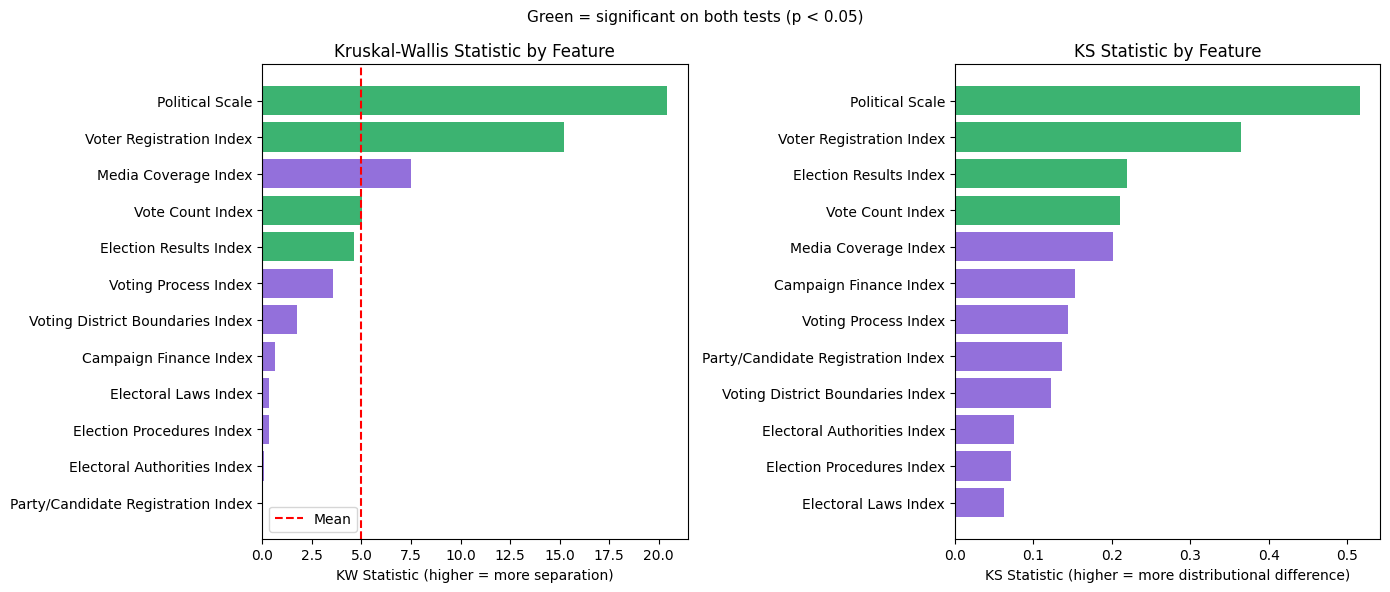

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Kruskal-Wallis statistics
results_df_sorted_kw = results_df.sort_values('KW Statistic', ascending=True)
axes[0].barh(results_df_sorted_kw['Feature'], results_df_sorted_kw['KW Statistic'], color=['mediumseagreen' if s == 'Yes' else 'mediumpurple' for s in results_df_sorted_kw['Significant']])
axes[0].axvline(x=results_df_sorted_kw['KW Statistic'].mean(), color='red', linestyle='--', label='Mean')
axes[0].set_title('Kruskal-Wallis Statistic by Feature')
axes[0].set_xlabel('KW Statistic (higher = more separation)')
axes[0].legend()

# KS statistics
results_df_sorted_ks = results_df.sort_values('KS Statistic', ascending=True)
axes[1].barh(results_df_sorted_ks['Feature'], results_df_sorted_ks['KS Statistic'], color=['mediumseagreen' if s == 'Yes' else 'mediumpurple' for s in results_df_sorted_ks['Significant']])
axes[1].set_title('KS Statistic by Feature')
axes[1].set_xlabel('KS Statistic (higher = more distributional difference)')

# Title
plt.suptitle('Green = significant on both tests (p < 0.05)', fontsize=11)
plt.tight_layout()
plt.show()

Reflections (green is significant, purple is not)

- Political scale is by far the most discriminatory feature (KW ~20.4, KS ~0.52). Groups have very different central tendancy and overall distribution.

- Voter registration index is also fairly discriminative. (KW ~15.2, KS ~0.37) 

- Vote count index and election results index both pass both tests but are relatively weak discriminators. 

- A few edge cases: media coverage index passes KW but fails KS. Suggests groups differ in median coverage, but overall distributions overlap. Voting process index is the opposite

- Non-significant features: Campaign finance index, electoral laws index, election procedures index, electoral authorities index, and party/candidate registration index

Note: 

- In EDA, electoral laws index and electoral authorities index looked like clear visual seperators in the 3 class boxplots, but here they have been shown to not be significant. This could be because Stein supporters rate these indices low and Trump supporters rate them high, so pooling them into an "Other" class causes signals to cancel each other out. This is a potential downside of the negative reframing of the problem. 

## Feature Preparation

Features selected are the same as regression's non-leaky features (the 11 sub-indices as well as political scale). 

Raw Likert items are excluded as well as demographics. EDA showed any differences between candidate groups could be attributed to sample size effects rather than genuine signal.

Pre-processing steps: 

- Ordinal encode Likert items 

- Median imputation for missing index values (EDA identified less than 5% missingness)

- StandardScaler for Logistic Regression and to ensure fair regualrisation across features.

In [6]:
# define features and split

feature_cols = index_cols + ['Political Scale']

target = 'target'

model_df = clf_df[feature_cols + [target]].dropna(subset=[target])
X = model_df[feature_cols]
y = model_df[target]

# Stratified split to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
print(f'\nTrain class distribution:')
print(y_train.value_counts().rename({0: 'Clinton', 1: 'Other'}))
print(f'\nTest class distribution:')
print(y_test.value_counts().rename({0: 'Clinton', 1: 'Other'}))


Train: 494 rows | Test: 124 rows

Train class distribution:
target
Clinton    458
Other       36
Name: count, dtype: int64

Test class distribution:
target
Clinton    115
Other        9
Name: count, dtype: int64


In [7]:
# Impute and scale

imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_imputed  = pd.DataFrame(imputer.transform(X_test),  columns=feature_cols, index=X_test.index)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=feature_cols, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_imputed),  columns=feature_cols, index=X_test.index)

## Feature Selection (RFECV)

Recursive Feature Elimination with Cross-Validation (RFECV) iteratively removes weakest feature and uses cross-validated performance to determine optimal number of features to keep. Logistic Regression is used as estimator.

Stratified k-fold (k=5) preserves class balance. Scoring is macro F1.

Features flagged as insignificant by KW and KS are expected to be eliminated.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(
    estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    step=1,
    cv=cv,
    scoring='f1_macro',
    min_features_to_select=1
)

rfecv.fit(X_train_scaled, y_train)

print(f'Optimal number of features: {rfecv.n_features_}')
print(f'\nFeatures selected:')

for feat, selected in zip(feature_cols, rfecv.support_):
    print(f'  {"Selected" if selected else "Not Selected"}  {feat}')

Optimal number of features: 9

Features selected:
  Selected  Electoral Laws Index
  Selected  Election Procedures Index
  Selected  Voting District Boundaries Index
  Not Selected  Voter Registration Index
  Selected  Party/Candidate Registration Index
  Selected  Media Coverage Index
  Selected  Campaign Finance Index
  Selected  Voting Process Index
  Not Selected  Vote Count Index
  Not Selected  Election Results Index
  Selected  Electoral Authorities Index
  Selected  Political Scale


Three features eliminated: voter registration index, vote count index and election results index. 

Vote count and election results were expected (both passed statistical tests but were weak discriminators)

Voter registration index was surpising. It was the second strongest feature as determined by the statistical tests but RFECV removed it. It's signal is likely already captured by Political Scale or one of the index columns. Statistical tests evaluate each feature independently whereas RFECV revaluates features in combination so this is likely why.

The final feature set of 9 features will be used for modelling. 

In [10]:
# Apply features chosen by RFECV

selected_features = [f for f, s in zip(feature_cols, rfecv.support_) if s]

X_train_selected = X_train_scaled[selected_features]
X_test_selected  = X_test_scaled[selected_features]

print(f'Feature set reduced from {len(feature_cols)} to {len(selected_features)} features')
print(f'Selected: {selected_features}')

Feature set reduced from 12 to 9 features
Selected: ['Electoral Laws Index', 'Election Procedures Index', 'Voting District Boundaries Index', 'Party/Candidate Registration Index', 'Media Coverage Index', 'Campaign Finance Index', 'Voting Process Index', 'Electoral Authorities Index', 'Political Scale']


## Imbalance Handling

The level of class imbalance means the model risks predicting Clinton for every observation. Four class imbalance strategies are compared, with Logistic Regerssion being used as a baseline estimator. 

Strategies:

- No handling (to show the effects of ignoring imbalance)

- Class weights (`class_weight='balanced'`)

- SMOTE

- SMOTE-ENN

SMOTE is applied inside cross-validation folds only, which stops synthetic samples from leaking into validation data.

In [13]:
# Baseline (no handling)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_base = LogisticRegression(max_iter=1000, random_state=42)

f1_base = cross_val_score(lr_base, X_train_selected, y_train, cv=cv, scoring='f1_macro')
roc_base = cross_val_score(lr_base, X_train_selected, y_train, cv=cv, scoring='roc_auc')

print(f'No handling:')
print(f'  Macro F1:  {f1_base.mean():.4f}')
print(f'  ROC-AUC:   {roc_base.mean():.4f}')


No handling:
  Macro F1:  0.5471
  ROC-AUC:   0.8162


In [15]:
# Class weights

lr_weighted = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

f1_weighted = cross_val_score(lr_weighted, X_train_selected, y_train, cv=cv, scoring='f1_macro')
roc_weighted = cross_val_score(lr_weighted, X_train_selected, y_train, cv=cv, scoring='roc_auc')

print(f'Class weights:')
print(f'  Macro F1:  {f1_weighted.mean():.4f}')
print(f'  ROC-AUC:   {roc_weighted.mean():.4f}')

Class weights:
  Macro F1:  0.5946
  ROC-AUC:   0.8226


In [17]:
# SMOTE

smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

f1_smote = cross_val_score(smote_pipeline, X_train_selected, y_train, cv=cv, scoring='f1_macro')
roc_smote = cross_val_score(smote_pipeline, X_train_selected, y_train, cv=cv, scoring='roc_auc')

print(f'SMOTE:')
print(f'  Macro F1:  {f1_smote.mean():.4f}')
print(f'  ROC-AUC:   {roc_smote.mean():.4f}')

SMOTE:
  Macro F1:  0.5988
  ROC-AUC:   0.8266


In [18]:
# SMOTE-ENN

smoteenn_pipeline = ImbPipeline([
    ('smoteenn', SMOTEENN(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

f1_smoteenn = cross_val_score(smoteenn_pipeline, X_train_selected, y_train, cv=cv, scoring='f1_macro')
roc_smoteenn = cross_val_score(smoteenn_pipeline, X_train_selected, y_train, cv=cv, scoring='roc_auc')

print(f'SMOTE-ENN:')
print(f'  Macro F1:  {f1_smoteenn.mean():.4f}')
print(f'  ROC-AUC:   {roc_smoteenn.mean():.4f}')

SMOTE-ENN:
  Macro F1:  0.5863
  ROC-AUC:   0.8236


In [19]:
# Comparison table

imbalance_results = pd.DataFrame({
    'Strategy':   ['No handling', 'Class weights', 'SMOTE', 'SMOTE-ENN'],
    'Macro F1':   [f1_base.mean(), f1_weighted.mean(), f1_smote.mean(), f1_smoteenn.mean()],
    'F1 Std':     [f1_base.std(),  f1_weighted.std(),  f1_smote.std(),  f1_smoteenn.std()],
    'ROC-AUC':    [roc_base.mean(), roc_weighted.mean(), roc_smote.mean(), roc_smoteenn.mean()],
    'AUC Std':    [roc_base.std(),  roc_weighted.std(),  roc_smote.std(),  roc_smoteenn.std()]
})

imbalance_results = imbalance_results.sort_values('Macro F1', ascending=False).reset_index(drop=True)
print(imbalance_results.round(4).to_string(index=False))

     Strategy  Macro F1  F1 Std  ROC-AUC  AUC Std
        SMOTE    0.5988  0.0114   0.8266   0.0390
Class weights    0.5946  0.0219   0.8226   0.0377
    SMOTE-ENN    0.5863  0.0257   0.8236   0.0408
  No handling    0.5471  0.0576   0.8162   0.0562


All three error handling strategies are better than no handling. 

SMOTE is the best strategy. It achieves the highest macro F1 (0.5988) and ROC-AUC (0.8266) and also lowest F1 standard deviation. Best performing and most stable across folds.

ROC-AUC being stable across all strategies implies underlying discriminative signal is consistent.

SMOTE is used for model training.

## Model Training

Three classifiers are trained and compared: Logistic Regression (baseline), Random Forest and XGBoost. Each is wrapped in an ImbPipeline with SMOTE and tuned with GridSearchCV using stratified 5-fold CV scores on macro-F1.

Helper functions handle pipeline construction, grid search execution and evaluation to keep code modular.

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def build_pipeline(classifier):
    """Wrap a classifier in an ImbPipeline with SMOTE."""
    return ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', classifier)
    ])

def run_gridsearch(pipeline, params, X_train, y_train):
    """Fit GridSearchCV, print best parameters and CV score, and return fitted grid."""
    grid = GridSearchCV(pipeline, params, cv=cv, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f'Best params: {grid.best_params_}')
    print(f'Best CV Macro F1: {grid.best_score_:.4f}')
    return grid


def evaluate_model(name, model, X_test, y_test):
    """
    - Print classification report and ROC-AUC.
    - Plot confusion matrix and ROC curve.
    - Return metrics dict for comparison table.
    """
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f'{name} (Test Set)')
    print(classification_report(y_test, y_pred, target_names=['Clinton', 'Other']))
    auc = roc_auc_score(y_test, y_proba)
    print(f'ROC-AUC: {auc:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Clinton', 'Other'], yticklabels=['Clinton', 'Other'])
    axes[0].set_title(f'Confusion Matrix — {name}')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve: {name}')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {
        'Model': name,
        'CV Macro F1': model.best_score_,
        'Test Macro F1': f1_score(y_test, y_pred, average='macro'),
        'ROC-AUC': auc,
        'y_proba': y_proba
    }


def plot_combined_roc(results, y_test):
    """Plot ROC curves for all models on one axes."""
    plt.figure(figsize=(8, 6))
    for r in results:
        fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
        plt.plot(fpr, tpr, label=f'{r["Model"]} (AUC = {r["ROC-AUC"]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves: All Models')
    plt.legend()
    plt.tight_layout()
    plt.show()


### Logistic Regression

Acts as a baseline

Best params: {'clf__C': 10, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Best CV Macro F1: 0.6055
Logistic Regression (Test Set)
              precision    recall  f1-score   support

     Clinton       0.96      0.75      0.84       115
       Other       0.15      0.56      0.23         9

    accuracy                           0.73       124
   macro avg       0.55      0.65      0.54       124
weighted avg       0.90      0.73      0.80       124

ROC-AUC: 0.6937


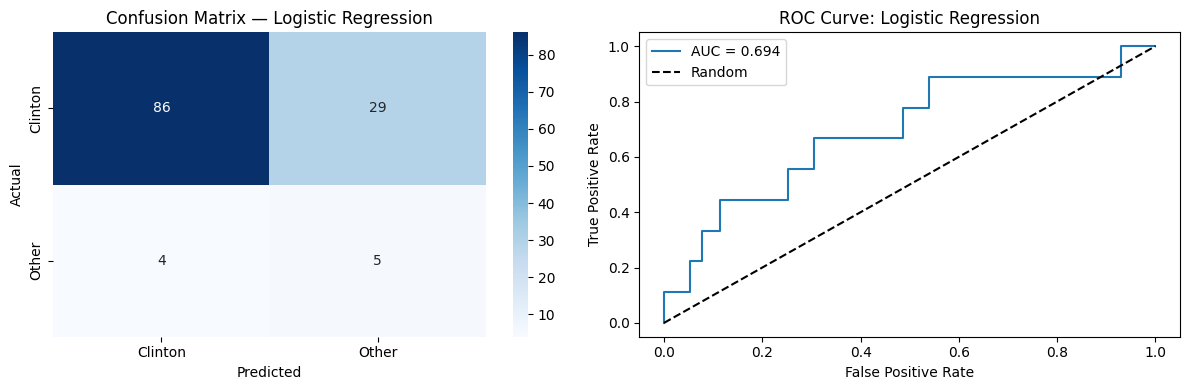

In [21]:
lr_params = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear']
}

lr_grid = run_gridsearch(
    build_pipeline(LogisticRegression(max_iter=1000, random_state=42)),
    lr_params, X_train_selected, y_train
)

lr_results = evaluate_model('Logistic Regression', lr_grid, X_test_selected, y_test)

### Random Forest

Best params: {'clf__max_depth': 5, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
Best CV Macro F1: 0.6671
Random Forest (Test Set)
              precision    recall  f1-score   support

     Clinton       0.95      0.89      0.92       115
       Other       0.24      0.44      0.31         9

    accuracy                           0.85       124
   macro avg       0.59      0.67      0.61       124
weighted avg       0.90      0.85      0.87       124

ROC-AUC: 0.6918


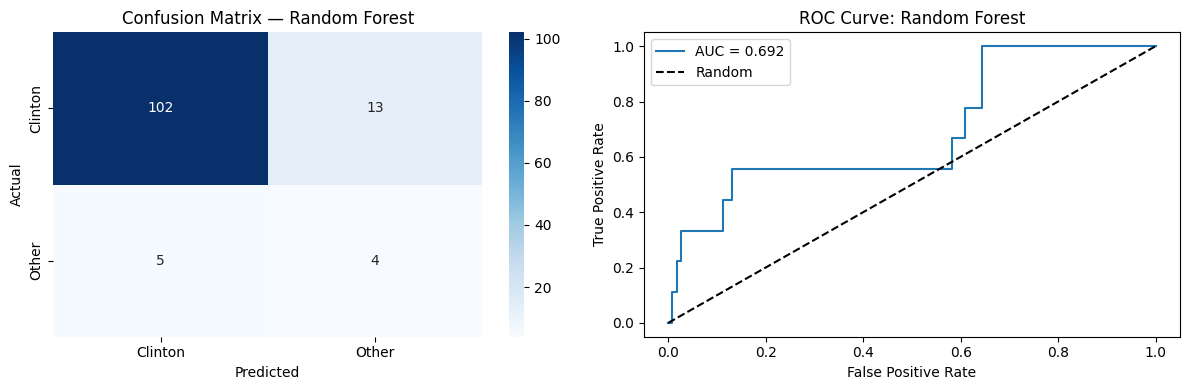

In [22]:
rf_params = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 5, 10, 15],
    'clf__min_samples_split': [2, 5, 10]
}

rf_grid = run_gridsearch(
    build_pipeline(RandomForestClassifier(random_state=42)),
    rf_params, X_train_selected, y_train
)

rf_results = evaluate_model('Random Forest', rf_grid, X_test_selected, y_test)

### XGBoost

Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 1.0}
Best CV Macro F1: 0.6890
XGBoost (Test Set)
              precision    recall  f1-score   support

     Clinton       0.95      0.91      0.93       115
       Other       0.23      0.33      0.27         9

    accuracy                           0.87       124
   macro avg       0.59      0.62      0.60       124
weighted avg       0.89      0.87      0.88       124

ROC-AUC: 0.7314


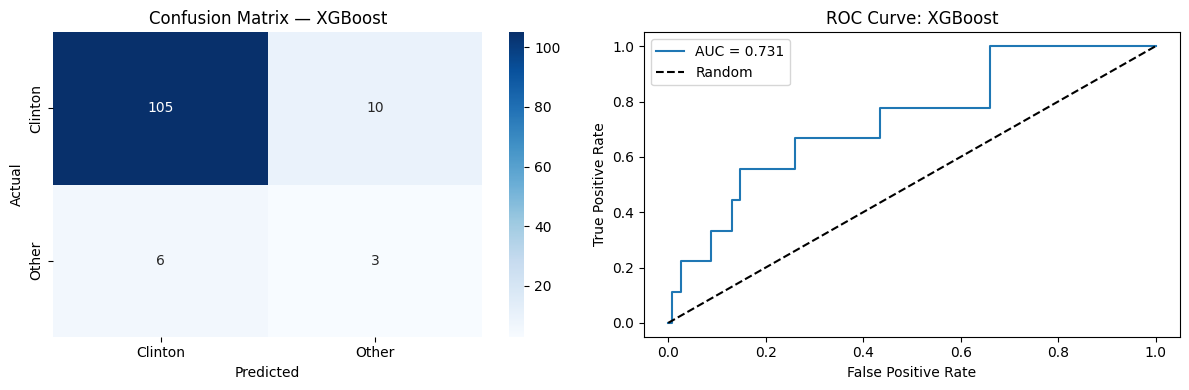

In [23]:
xgb_params = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__subsample': [0.8, 1.0]
}

xgb_grid = run_gridsearch(
    build_pipeline(XGBClassifier(random_state=42, eval_metric='logloss')),
    xgb_params, X_train_selected, y_train
)

xgb_results = evaluate_model('XGBoost', xgb_grid, X_test_selected, y_test)

### Model Comparison

              Model  CV Macro F1  Test Macro F1  ROC-AUC
      Random Forest       0.6671         0.6133   0.6918
            XGBoost       0.6890         0.6010   0.7314
Logistic Regression       0.6055         0.5358   0.6937


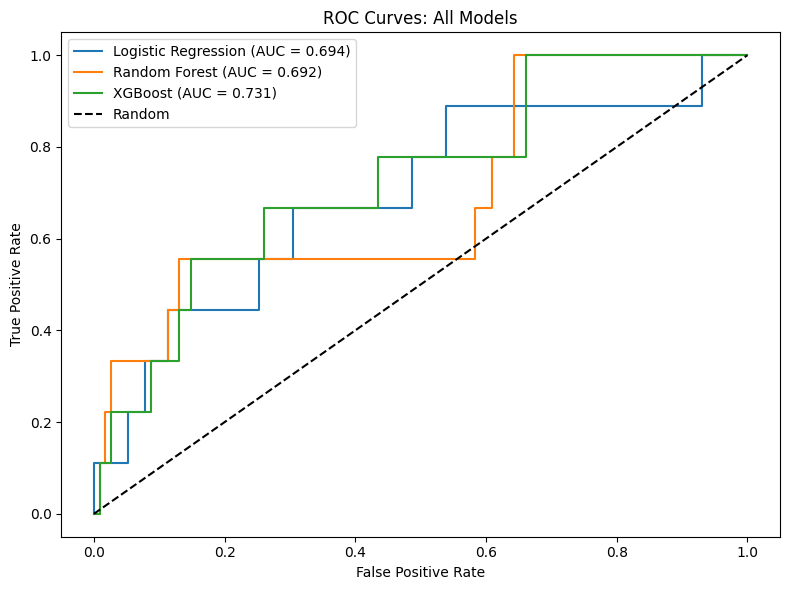

In [24]:
all_results = [lr_results, rf_results, xgb_results]

comparison = pd.DataFrame(all_results).drop(columns='y_proba')
comparison = comparison.sort_values('Test Macro F1', ascending=False).reset_index(drop=True)
print(comparison.round(4).to_string(index=False))

plot_combined_roc(all_results, y_test)

All three models improve significantly over a naive baseline. LR underperforms both ensemble methods, which suggests non-linear structure.

RF has highest test macro F1 (0.613) while XGBoost achieves highest ROC-AUC (0.731) and CV macro F1 (0.689). The gap between CV and test F1 is largest for XGBoost (0.088), but with only 9 Other observations in the test set, single prediction differences will signifcantly affect F1.

XGBoost is selected for calibration. ROC-AUC is the most direct measure of probability quality, and XGBoost's 0.731 vs RF's 0.692 indicates stronger discriminative ability in its probability estimates (what calibration is designed to refine).